In [1]:
import numpy as np              # Manejo de arrays y funciones generales
import matplotlib.pyplot as plt # Manejo de graficos
import specdal                  # Manejo de espectros
import json                     # Manejo de json

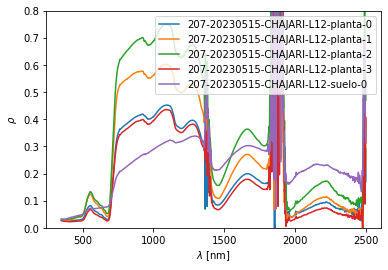

In [12]:
# Creo la colección para los espectros
collection_radiances = specdal.Collection(name="Chajari", measure_type="tgt_radiance")
collection_reflectances = specdal.Collection(name="Chajari", measure_type="tgt_reflectance")

# Defino las carpetas con la información
main_folder = "../datos/chajari_mayo2023/radiometro/datos_chajari/207-20230515-Chajari/"
sub_folder = "Radiometria/Rad CorrPar/"
folders = ["L12-nombre de la cobertura"]

#folders = ["L1-nombre de la cobertura", "L2-nombre de la cobertura"]

# Leo los espectros en cada carpeta
for folder in folders:
    directory = f"{main_folder}/{folder}/{sub_folder}/"
    collection_radiances.read(directory=directory,         # Directorio con los datos
                              ext=['.pco'],                # Extensión de los archivos a leer
                              reader=".asd",               # Tipo de archivo
                              measure_type="tgt_radiance") # Medición de interés
# Elimino la extensión dne los nombres de los espectros  
for spectra in collection_radiances.spectra:
    spectra.name = spectra.name.replace(".asd.rad","")
    spectra.name = spectra.name[:20]+"-"+\
                   folder.split('-')[0]+"-"+\
                   spectra.name[20:22]+"-"+\
                   spectra.name[22:]
    spectra.name = spectra.name +"-"+\
                   str(int(spectra.name.split('-')[-1])//10)

name = spectra.name
name = "-".join(name.split('-')[0:4])

groupby_radiances = collection_radiances.groupby("-",[-1])

#Calculo reflectancias

rho1 = groupby_radiances["1"].mean()/groupby_radiances["0"].mean()
rho1.name = name +"-"+"planta-0"
collection_reflectances.append(rho1)
rho2 = groupby_radiances["3"].mean()/groupby_radiances["2"].mean()
rho2.name = name +"-"+"planta-1"
collection_reflectances.append(rho2)
rho3 = groupby_radiances["5"].mean()/groupby_radiances["4"].mean()
rho3.name = name +"-"+"planta-2"
collection_reflectances.append(rho3)
rho4 = groupby_radiances["7"].mean()/groupby_radiances["6"].mean()
rho4.name = name +"-"+"planta-3"
collection_reflectances.append(rho4)
rho5 = groupby_radiances["9"].mean()/groupby_radiances["8"].mean()
rho5.name = name +"-"+"suelo-0"
collection_reflectances.append(rho5)


# Grafico

collection_reflectances.plot()
plt.ylim(0,0.8)
plt.xlabel(r"$\lambda$ [nm]")
plt.ylabel(r"$\rho$")
plt.show()

In [3]:
#collection_radiances.plot()
collection_radiances.data

,207-20230515-CHAJARI-L1-01-000-0,207-20230515-CHAJARI-L1-01-001-0,207-20230515-CHAJARI-L1-01-002-0,207-20230515-CHAJARI-L1-01-003-0,207-20230515-CHAJARI-L1-01-004-0,207-20230515-CHAJARI-L1-01-005-0,207-20230515-CHAJARI-L1-01-006-0,207-20230515-CHAJARI-L1-01-007-0,207-20230515-CHAJARI-L1-01-008-0,207-20230515-CHAJARI-L1-01-009-0,...,207-20230515-CHAJARI-L1-01-090-9,207-20230515-CHAJARI-L1-01-091-9,207-20230515-CHAJARI-L1-01-092-9,207-20230515-CHAJARI-L1-01-093-9,207-20230515-CHAJARI-L1-01-094-9,207-20230515-CHAJARI-L1-01-095-9,207-20230515-CHAJARI-L1-01-096-9,207-20230515-CHAJARI-L1-01-097-9,207-20230515-CHAJARI-L1-01-098-9,207-20230515-CHAJARI-L1-01-099-9
wavelength,,,,,,,,,,,,,,,,,,,,,
350.0,0.026481,0.026260,0.026684,0.027888,0.028491,0.029256,0.031302,0.031775,0.032240,0.031852,...,0.001235,0.001248,0.001283,0.001258,0.001219,0.001243,0.001251,0.001246,0.001226,0.001235
351.0,0.026642,0.026416,0.026829,0.028065,0.028673,0.029464,0.031525,0.032050,0.032488,0.032069,...,0.001234,0.001239,0.001305,0.001262,0.001248,0.001241,0.001256,0.001244,0.001252,0.001249
352.0,0.026839,0.026600,0.026980,0.028249,0.028914,0.029698,0.031785,0.032313,0.032769,0.032361,...,0.001257,0.001234,0.001299,0.001256,0.001236,0.001242,0.001257,0.001253,0.001223,0.001228
353.0,0.027214,0.026995,0.027396,0.028682,0.029353,0.030173,0.032337,0.032843,0.033321,0.032896,...,0.001253,0.001242,0.001321,0.001284,0.001262,0.001299,0.001263,0.001268,0.001259,0.001242
354.0,0.027618,0.027418,0.027826,0.029136,0.029815,0.030655,0.032864,0.033406,0.033865,0.033421,...,0.001270,0.001273,0.001349,0.001311,0.001285,0.001322,0.001286,0.001292,0.001299,0.001269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2496.0,-0.000020,0.000233,0.000153,0.000094,0.000121,0.000341,0.000264,0.000413,0.000267,0.000207,...,0.000311,0.000075,0.000153,0.000148,0.000112,0.000276,0.000043,0.000268,-0.000040,-0.000020
2497.0,-0.000019,0.000265,0.000198,0.000157,0.000106,0.000319,0.000392,0.000467,0.000299,0.000228,...,0.000346,-0.000017,0.000190,0.000181,0.000091,0.000208,0.000048,0.000323,-0.000023,-0.000092
2498.0,0.000047,0.000290,0.000257,0.000180,0.000158,0.000315,0.000500,0.000482,0.000293,0.000275,...,0.000308,-0.000056,0.000254,0.000181,0.000047,0.000194,0.000108,0.000351,-0.000012,-0.000050


In [4]:
#Acomodamos y reordenamos los nombres

#spectra.name[:20]+"-"+folder.split('-')[0]+"-"+spectra.name[20:22]+"-"+spectra.name[22:]
str(int(spectra.name.split('-')[-1])//10)

'0'

In [13]:
groupby_radiances = collection_radiances.groupby("-",[-1])


In [6]:
groupby_radiances["0"].data #primer espectralon
# los espectralones son los pares
# planta los impares
# suelo es el 9

,207-20230515-CHAJARI-L1-01-000-0,207-20230515-CHAJARI-L1-01-001-0,207-20230515-CHAJARI-L1-01-002-0,207-20230515-CHAJARI-L1-01-003-0,207-20230515-CHAJARI-L1-01-004-0,207-20230515-CHAJARI-L1-01-005-0,207-20230515-CHAJARI-L1-01-006-0,207-20230515-CHAJARI-L1-01-007-0,207-20230515-CHAJARI-L1-01-008-0,207-20230515-CHAJARI-L1-01-009-0
wavelength,,,,,,,,,,
350.0,0.026481,0.026260,0.026684,0.027888,0.028491,0.029256,0.031302,0.031775,0.032240,0.031852
351.0,0.026642,0.026416,0.026829,0.028065,0.028673,0.029464,0.031525,0.032050,0.032488,0.032069
352.0,0.026839,0.026600,0.026980,0.028249,0.028914,0.029698,0.031785,0.032313,0.032769,0.032361
353.0,0.027214,0.026995,0.027396,0.028682,0.029353,0.030173,0.032337,0.032843,0.033321,0.032896
354.0,0.027618,0.027418,0.027826,0.029136,0.029815,0.030655,0.032864,0.033406,0.033865,0.033421
...,...,...,...,...,...,...,...,...,...,...
2496.0,-0.000020,0.000233,0.000153,0.000094,0.000121,0.000341,0.000264,0.000413,0.000267,0.000207
2497.0,-0.000019,0.000265,0.000198,0.000157,0.000106,0.000319,0.000392,0.000467,0.000299,0.000228
2498.0,0.000047,0.000290,0.000257,0.000180,0.000158,0.000315,0.000500,0.000482,0.000293,0.000275


In [8]:
rho1.name

'207-20230515-CHAJARI-L1-planta-0'

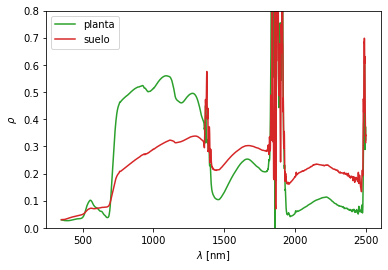

In [20]:
groupby_reflectances = collection_reflectances.groupby("-",[-2])
rho_planta_mean = groupby_reflectances["planta"].mean()
rho_suelo_mean = groupby_reflectances["suelo"].mean()

rho_planta_mean.plot(label = "planta", color = "C2")
rho_suelo_mean.plot(label = "suelo", color = "C3")
plt.legend()
plt.ylim(0,0.8)
plt.xlabel(r"$\lambda$ [nm]")
plt.ylabel(r"$\rho$")
plt.show()